# 지역별 차이 분석 (EDA_region)

**질문: 학교안전사고는 지역(시도)별로 실제 차이가 있는가?**

세 층위로 나눠 검증한다.
1. **발생량(절대)** — 지역차가 커 보이지만 대부분 *학생 수 규모*의 반영 → 정규화 필요.
2. **사고 유형 구성** — 어떤 사고가 나는지의 *구성비*는 지역 간 다른가? (구성비라 인구규모와 무관)
3. **심각도(평균 보상액)** — 같은 사고라도 지역별로 *더 크게* 다치는가?

> 대회 제공 데이터(외부 공개 금지). 시계열이 아닌 지역 단면 분석이라 발생·보상 전체를 사용.

## 0. 로드 & 헬퍼

In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import eda_utils as E

FIG='../Docs/figures'; os.makedirs(FIG, exist_ok=True)
def save(n): plt.savefig(f'{FIG}/{n}', dpi=120, bbox_inches='tight')

occ = E.load_occ(); comp = E.load_comp()

def cramers_v(a, b):
    """두 범주형 변수의 연관성 효과크기(0~1). 0.1미만=미미, 0.3미만=약함."""
    tab = pd.crosstab(a, b); chi2 = chi2_contingency(tab)[0]
    n = tab.values.sum(); k = min(tab.shape)-1
    return np.sqrt(chi2/(n*k))

REGION_N = occ['지역'].nunique()
print('지역 수:', REGION_N, '| 발생', len(occ), '| 보상', len(comp))

지역 수: 17 | 발생 865384 | 보상 528503


## 1. 발생량(절대) — "커 보이는 지역차"의 함정

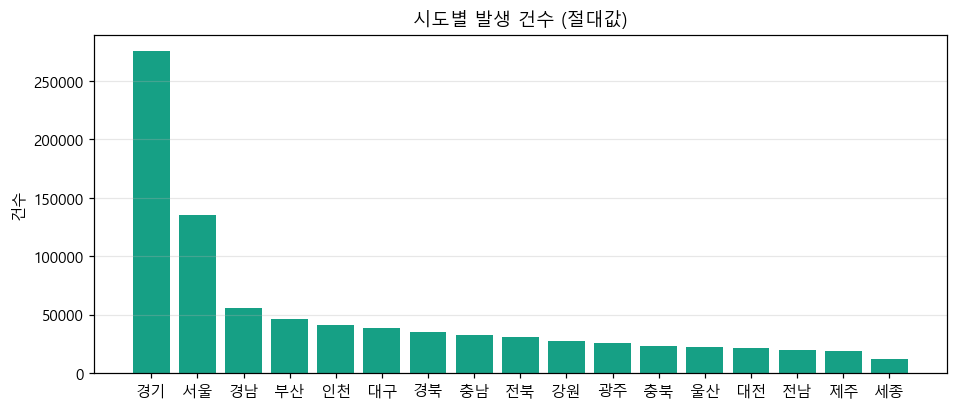

상위3: 경기 31.9%, 서울 15.6%, 경남 6.5%
경기/제주 배수: 14.7


In [2]:
# [그림] 지역별 절대 발생 건수: 경기·서울이 압도 — 그러나 이는 학생 수 규모
reg = occ['지역'].value_counts()
fig, ax = plt.subplots(figsize=(10,4))
ax.bar(reg.index, reg.values, color='#16a085')
ax.set_title('시도별 발생 건수 (절대값)'); ax.set_ylabel('건수'); ax.grid(axis='y',alpha=.3)
save('reg_fig1_절대건수.png'); plt.show()
print('상위3:', ', '.join(f'{k} {v/len(occ)*100:.1f}%' for k,v in reg.head(3).items()))
print('경기/제주 배수:', round(reg['경기']/reg['제주'],1))

> 경기(31.9%)·서울(15.6%)이 최다지만 **경기는 제주의 약 15배** — 이는 위험도가 아니라 **학생 수 차이**.
> **정규화 필수**: `발생건수 ÷ 학생수 × 1,000`(학생 1천명당 발생률).
> **권장 외부데이터**: 한국교육개발원 KESS(https://kess.kedi.re.kr) 또는 KOSIS *시도·학교급별 학생 수*.
> → 절대건수만으로는 "지역별 위험 차이"를 말할 수 없다.

## 2. 사고 유형 구성 — 지역마다 '나는 사고의 종류'가 다른가?

구성비(행 정규화)는 인구규모와 무관하므로 정규화 없이 비교 가능.
표본이 86만 건이라 웬만한 차이도 카이제곱 p값은 0에 수렴 → **효과크기(Cramér's V)**로 판단한다.

In [3]:
# 지역 vs 여러 속성의 연관성 효과크기 -> 모두 매우 약함(V<0.1): 유형 '구성'은 지역 대동소이
dims = ['학교급','사고시간','사고장소','사고형태','사고부위','사고당시활동','사고자성별']
rows=[]
for d in dims:
    tab=pd.crosstab(occ['지역'],occ[d]); chi2,p,dof,_=chi2_contingency(tab)
    rows.append({'속성':d,'chi2':chi2,'p값':p,'CramersV':cramers_v(occ['지역'],occ[d])})
eff=pd.DataFrame(rows).sort_values('CramersV',ascending=False)
print(eff.to_string(index=False))

    속성         chi2           p값  CramersV
   학교급 10774.094676 0.000000e+00  0.049900
사고당시활동 19468.606635 0.000000e+00  0.037498
  사고시간 18802.445968 0.000000e+00  0.036850
  사고장소 18295.600405 0.000000e+00  0.036350
  사고형태  8154.790938 0.000000e+00  0.024268
 사고자성별   501.985212 1.266852e-96  0.024085
  사고부위  6220.628055 0.000000e+00  0.021196


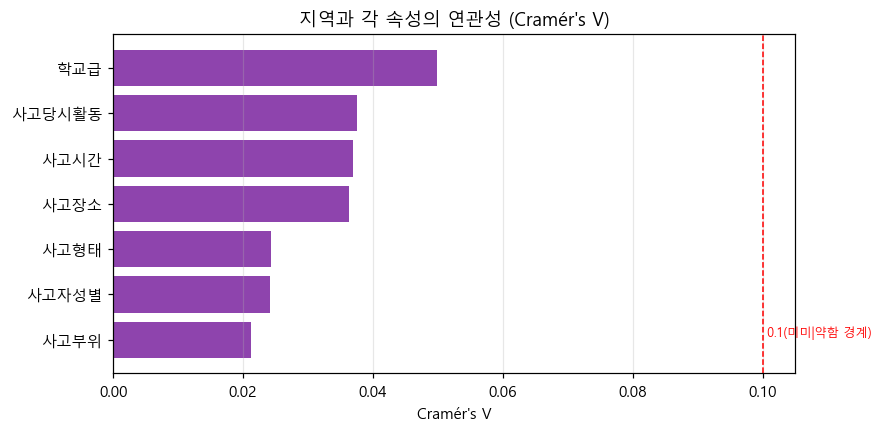

최대 효과크기: 학교급 0.05


In [4]:
# [그림] 지역 연관성 효과크기: p는 모두 유의하나 V는 전부 '미미' 구간
fig, ax = plt.subplots(figsize=(8,4))
ax.barh(eff['속성'][::-1], eff['CramersV'][::-1], color='#8e44ad')
ax.axvline(0.1, color='red', ls='--', lw=1); ax.text(0.1,0,' 0.1(미미|약함 경계)', color='red', fontsize=8, va='bottom')
ax.set_title("지역과 각 속성의 연관성 (Cramér's V)"); ax.set_xlabel("Cramér's V"); ax.grid(axis='x',alpha=.3)
save('reg_fig2_효과크기.png'); plt.show()
print('최대 효과크기:', eff.iloc[0]['속성'], round(eff.iloc[0]['CramersV'],3))

> **모든 속성의 Cramér's V < 0.06 (미미).** 즉 표본이 커서 "통계적으로 유의(p≈0)"하지만 **실질적 차이는 작다**.
> → *어떤 종류의 사고가 나는지의 구성*은 전국이 대체로 비슷하다. (**큰 데이터의 함정: 유의성 ≠ 중요성**)

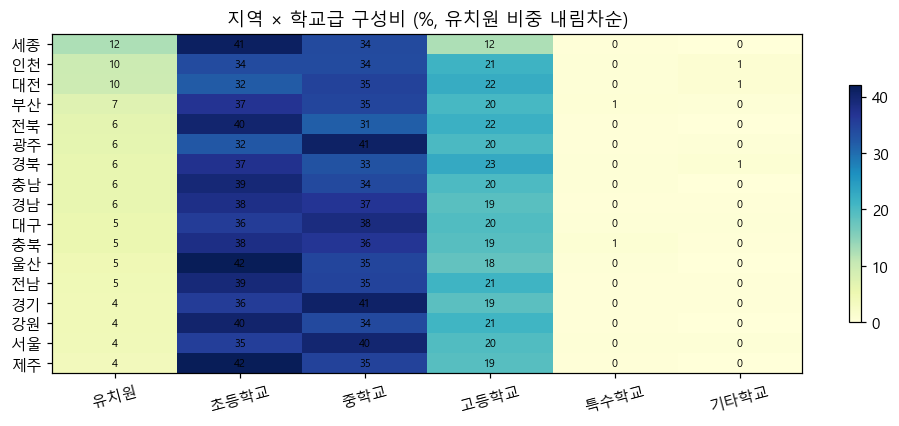

In [5]:
# 그래도 가장 연관 큰 '학교급/장소' 구성 차이를 눈으로 확인 -> 세종=유치원↑, 제주=운동장↑
ct = pd.crosstab(occ['지역'], occ['학교급'], normalize='index')*100
ct = ct.reindex(columns=['유치원','초등학교','중학교','고등학교','특수학교','기타학교'])
ct = ct.sort_values('유치원', ascending=False)
fig, ax = plt.subplots(figsize=(11,4))
im=ax.imshow(ct.values, cmap='YlGnBu', aspect='auto')
ax.set_xticks(range(ct.shape[1])); ax.set_xticklabels(ct.columns, rotation=15)
ax.set_yticks(range(ct.shape[0])); ax.set_yticklabels(ct.index)
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j,i,f'{ct.values[i,j]:.0f}',ha='center',va='center',fontsize=7)
ax.set_title('지역 × 학교급 구성비 (%, 유치원 비중 내림차순)'); fig.colorbar(im,shrink=.7)
save('reg_fig3_학교급구성.png'); plt.show()

> 미세하지만 특성은 있음: **세종·인천·대전은 유치원 비중↑**(신도시·젊은 인구), **세종은 고교 비중 최저(12%)**. 지역 인구구조가 사고 구성에 그대로 반영.

## 3. 심각도 — 같은 사고여도 지역별로 '더 크게' 다치는가? (핵심)

발생 건수가 아니라 **보상금액**으로 보면 지역차가 뚜렷해진다.

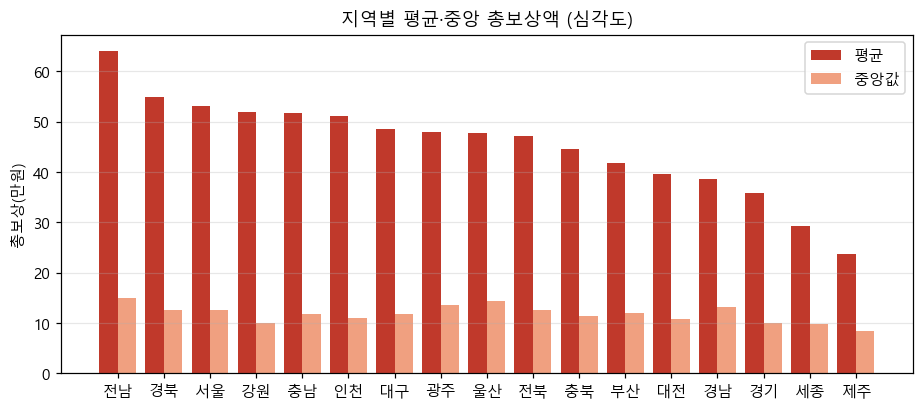

평균 최고/최저: 전남 64.1 만 vs 제주 23.8 만 → 배수 2.7


In [6]:
# [그림] 지역별 평균/중앙 총보상: 전남·경북 高 vs 제주·세종 低. 평균은 고액사고 꼬리에 민감
g = comp.groupby('지역')['총보상'].agg(평균='mean', 중앙='median', 건수='size').sort_values('평균', ascending=False)
fig, ax = plt.subplots(figsize=(10,4))
x=np.arange(len(g))
ax.bar(x-0.2, g['평균']/1e4, 0.4, label='평균', color='#c0392b')
ax.bar(x+0.2, g['중앙']/1e4, 0.4, label='중앙값', color='#f0a080')
ax.set_xticks(x); ax.set_xticklabels(g.index); ax.set_ylabel('총보상(만원)')
ax.set_title('지역별 평균·중앙 총보상액 (심각도)'); ax.legend(); ax.grid(axis='y',alpha=.3)
save('reg_fig4_지역심각도.png'); plt.show()
print('평균 최고/최저:', g.index[0], round(g['평균'].iloc[0]/1e4,1),'만 vs',
      g.index[-1], round(g['평균'].iloc[-1]/1e4,1),'만 → 배수', round(g['평균'].iloc[0]/g['평균'].iloc[-1],2))

> **가장 뚜렷한 지역차는 '심각도'.** 평균 총보상 **전남 64만 vs 제주 24만 → 2.7배**.
> 평균-중앙값 격차가 큰 지역(강원·경기)은 **소수 고액사고**가 평균을 끌어올린 것 → 지역별 고액사고 발생 구조 차이 시사.

### 3-1. 강건성 체크 — 상위 1% 고액사고 제거

전남 vs 제주 2.7배 차이가 *소수 고액사고(장해·중상)* 때문인지, 일반 사고에서도 유지되는지 확인.
전체 총보상 **99% 분위(약 335만원) 이상을 제거**한 뒤 지역 평균을 재계산한다.

In [7]:
# 상위1% 제거 전/후 지역 평균 비교 -> 배수 2.7 → 1.88로 축소, 순위 급변
thr = comp['총보상'].quantile(0.99)
trim = comp[comp['총보상'] < thr]
full_m = comp.groupby('지역')['총보상'].mean()
trim_m = trim.groupby('지역')['총보상'].mean()
cmp = pd.DataFrame({'전체':full_m, '절사(상위1%제거)':trim_m})
cmp['감소율%'] = (1 - cmp['절사(상위1%제거)']/cmp['전체'])*100
cmp = cmp.sort_values('절사(상위1%제거)', ascending=False)
print(f'99% 임계 {thr:,.0f}원, 제거 {(comp["총보상"]>=thr).sum():,}건 ({(comp["총보상"]>=thr).mean()*100:.2f}%)')
print(f'전체 배수 {full_m.max()/full_m.min():.2f}({full_m.idxmax()}/{full_m.idxmin()}) '
      f'→ 절사 배수 {trim_m.max()/trim_m.min():.2f}({trim_m.idxmax()}/{trim_m.idxmin()})')
print(cmp.round(0).to_string())

99% 임계 3,351,000원, 제거 5,291건 (1.00%)
전체 배수 2.70(전남/제주) → 절사 배수 1.88(광주/제주)
          전체  절사(상위1%제거)  감소율%
지역                            
광주  478565.0    349805.0  27.0
전남  641064.0    347208.0  46.0
울산  476503.0    328239.0  31.0
부산  418004.0    324146.0  22.0
충남  516867.0    317960.0  38.0
대구  484845.0    315559.0  35.0
충북  445996.0    313273.0  30.0
전북  470703.0    311753.0  34.0
서울  531723.0    310686.0  42.0
경북  548069.0    310168.0  43.0
인천  511684.0    302902.0  41.0
경남  386276.0    280569.0  27.0
대전  396689.0    266228.0  33.0
경기  357349.0    259981.0  27.0
강원  519513.0    237112.0  54.0
세종  292469.0    234906.0  20.0
제주  237654.0    186170.0  22.0


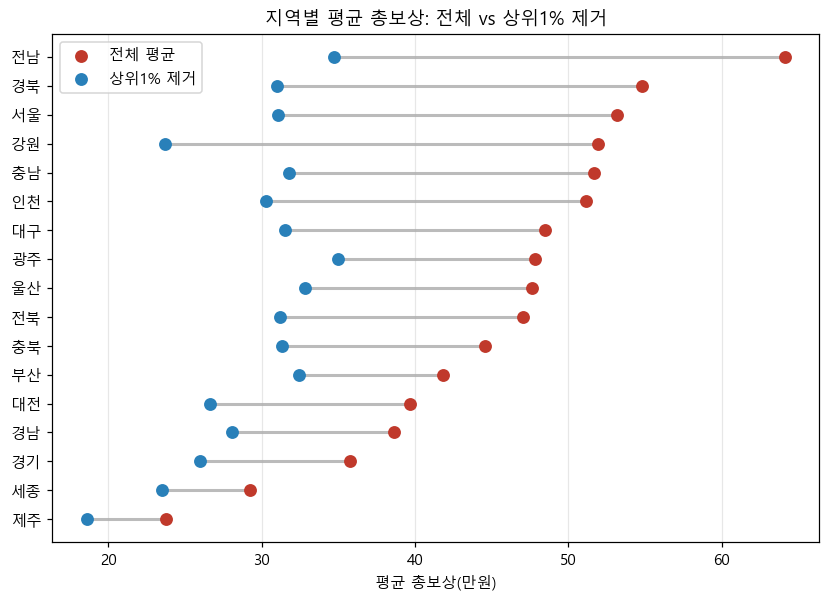

In [8]:
# [그림] 덤벨: 상위1% 제거 시 지역 평균이 얼마나 내려앉는가 (선이 길수록 고액사고 의존↑)
d = cmp.sort_values('전체', ascending=True)
fig, ax = plt.subplots(figsize=(9,6))
y = np.arange(len(d))
ax.hlines(y, d['절사(상위1%제거)']/1e4, d['전체']/1e4, color='#bbb', lw=2, zorder=1)
ax.scatter(d['전체']/1e4, y, s=55, color='#c0392b', label='전체 평균', zorder=2)
ax.scatter(d['절사(상위1%제거)']/1e4, y, s=55, color='#2980b9', label='상위1% 제거', zorder=2)
ax.set_yticks(y); ax.set_yticklabels(d.index); ax.set_xlabel('평균 총보상(만원)')
ax.set_title('지역별 평균 총보상: 전체 vs 상위1% 제거'); ax.legend(); ax.grid(axis='x', alpha=.3)
save('reg_fig6_절사덤벨.png'); plt.show()

> **선(막대)이 길수록 = 소수 고액사고가 평균을 끌어올린 정도가 큼.**
> - **강원 −54%, 전남 −46%, 경북 −43%, 서울 −42%**: 이 지역의 높은 평균은 *극소수 중증사고*가 견인 → 4분면 '좌상단(적지만 심각)' 가설 확인.
> - 광주·부산·제주는 감소율 낮음 → *일상적 사고비용* 자체의 차이.
> - **절사 후에도 최고/최저 1.88배는 잔존** → 일반 사고 심각도에도 지역차는 (약화되지만) 존재.

### 3-2. 지역 간 평균 차이의 가설검정 (원본 vs 절사)

**H0: 모든 시도의 평균 총보상이 같다.** 총보상은 극단적 우편향+이분산이라 세 검정을 병행한다.
- **일반 ANOVA / Welch ANOVA**(이분산 보정) — 평균 차이의 유의성 + 효과크기 η²/np².
- **Kruskal-Wallis**(순위 기반, 극단값에 강건) — 분포 차이 + ε².
- 표본이 52만이라 p값은 대부분 0에 수렴 → **효과크기(η²·ε²·Hedges g)로 '정도'를 판단**.
- 효과크기 해석: η²/ε² 0.01=작음·0.06=중간·0.14=큼 / Hedges g 0.2=작음·0.5=중간.

In [9]:
# 옴니버스 검정 3종을 원본/절사에 각각 적용
from scipy import stats as sstats
import pingouin as pg
thr = comp['총보상'].quantile(0.99)
def omnibus(df):
    grp=[g['총보상'].values for _,g in df.groupby('지역')]; k=df['지역'].nunique(); n=len(df)
    F,pF=sstats.f_oneway(*grp)
    grand=df['총보상'].mean()
    eta2=sum(len(g)*(g.mean()-grand)**2 for g in grp)/((df['총보상']-grand)**2).sum()
    wa=pg.welch_anova(data=df,dv='총보상',between='지역')
    H,pH=sstats.kruskal(*grp); eps2=(H-k+1)/(n-k)
    return {'n':n,'ANOVA F':F,'ANOVA p':pF,'η²':eta2,
            'Welch F':wa['F'][0],'Welch p':wa['p_unc'][0],
            'KW H':H,'KW p':pH,'ε²':eps2}
res=pd.DataFrame({'원본(전체)':omnibus(comp),
                  '절사(상위1%제거)':omnibus(comp[comp['총보상']<thr])}).T
pd.set_option('display.float_format', lambda v:f'{v:.4g}')
print(res.to_string()); pd.reset_option('display.float_format')

                   n  ANOVA F   ANOVA p        η²  Welch F   Welch p  KW H  KW p      ε²
원본(전체)     5.285e+05      7.8 6.558e-19 0.0002361    15.26 8.885e-43  6896     0 0.01302
절사(상위1%제거) 5.232e+05    158.2         0  0.004815    184.5         0  6744     0 0.01286


> 세 검정 모두 **p ≪ 0.001 → H0 기각**(지역 평균 차이는 통계적으로 유의).
> 그러나 **원본 η²=0.0002**(지역이 총보상 분산의 0.02%만 설명) — *유의하지만 효과는 사실상 0*.
> **절사 후 η²=0.0048로 24배↑** — 극단 고액사고(잡음)를 걷어내자 지역차가 선명해짐.
> 순위 기반 **ε²는 0.013으로 원본·절사 동일** → 지역차는 원래 순위상 일관되게 존재했음을 방증.

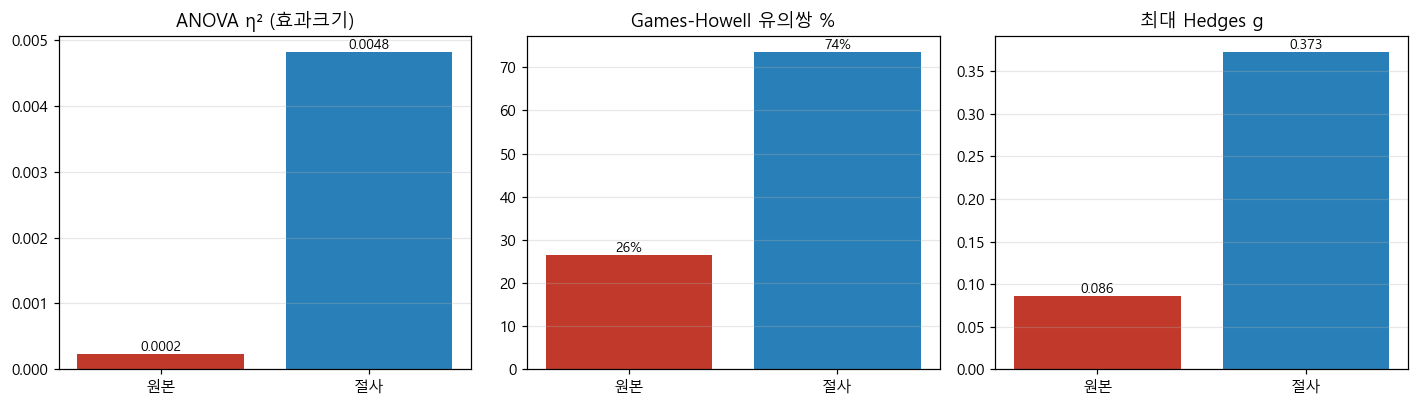

유의쌍: 원본 26% → 절사 74% | 최대 g: 0.086 → 0.373


In [10]:
# [그림] 효과크기·유의쌍 비교: 절사하면 '정도'가 오히려 커진다
def gh_sig(df):
    g=pg.pairwise_gameshowell(data=df,dv='총보상',between='지역')
    return (g['pval']<0.05).mean()*100, g['hedges'].abs().max(), g
s_full,g_full,gh_full = gh_sig(comp)
s_trim,g_trim,gh_trim = gh_sig(comp[comp['총보상']<thr])
fig, axes = plt.subplots(1,3, figsize=(13,3.8))
def pair(ax,vals,title,fmt='{:.4f}'):
    b=ax.bar(['원본','절사'],vals,color=['#c0392b','#2980b9'])
    ax.set_title(title); ax.grid(axis='y',alpha=.3)
    for r,v in zip(b,vals): ax.text(r.get_x()+r.get_width()/2, v, fmt.format(v), ha='center', va='bottom', fontsize=9)
pair(axes[0],[res.loc['원본(전체)','η²'],res.loc['절사(상위1%제거)','η²']],'ANOVA η² (효과크기)')
pair(axes[1],[s_full,s_trim],'Games-Howell 유의쌍 %','{:.0f}%')
pair(axes[2],[g_full,g_trim],'최대 Hedges g','{:.3f}')
plt.tight_layout(); save('reg_fig7_효과크기비교.png'); plt.show()
print(f'유의쌍: 원본 {s_full:.0f}% → 절사 {s_trim:.0f}% | 최대 g: {g_full:.3f} → {g_trim:.3f}')

> **절사 후 유의쌍 26%→74%, 최대 Hedges g 0.09→0.37.** 평균 *격차(배수)*는 줄지만(2.7→1.88) 통계적 *구별력*은 커짐 — 고액사고는 지역 무관 랜덤 잡음이었음을 뒷받침.

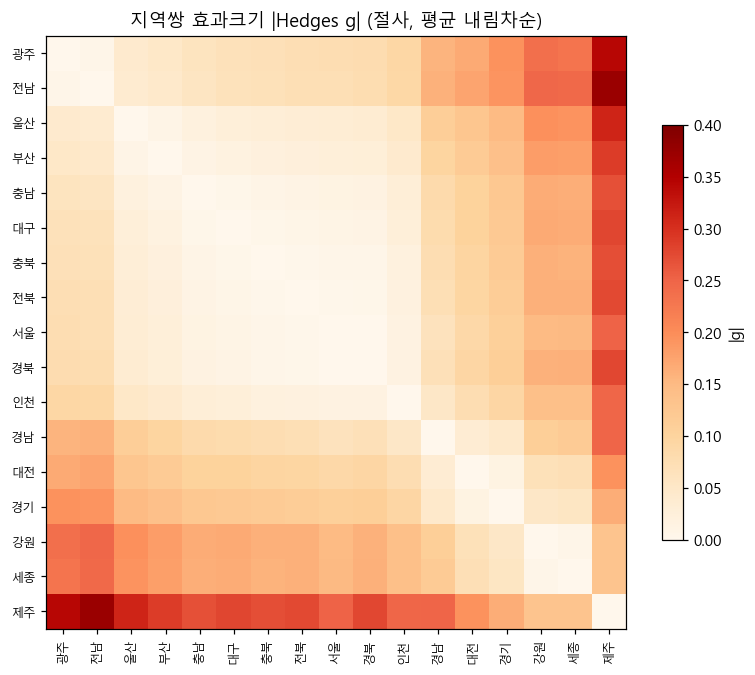

가장 큰 차이 쌍: {'A': '전남', 'B': '제주', 'hedges': 0.37269272391223424}


In [11]:
# [그림] 절사 기준 지역쌍 Hedges g 히트맵 — '어느 지역끼리 얼마나 다른가'
order = comp[comp['총보상']<thr].groupby('지역')['총보상'].mean().sort_values(ascending=False).index.tolist()
M = pd.DataFrame(0.0, index=order, columns=order)
for _,r in gh_trim.iterrows():
    M.loc[r.A,r.B]=r.hedges; M.loc[r.B,r.A]=-r.hedges
fig, ax = plt.subplots(figsize=(8.5,7))
im=ax.imshow(M.abs().values, cmap='OrRd', aspect='auto', vmin=0, vmax=0.4)
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=90, fontsize=8)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=8)
ax.set_title('지역쌍 효과크기 |Hedges g| (절사, 평균 내림차순)'); fig.colorbar(im,shrink=.7,label='|g|')
save('reg_fig8_지역쌍효과크기.png'); plt.show()
print('가장 큰 차이 쌍:', gh_trim.loc[gh_trim.hedges.abs().idxmax(),['A','B','hedges']].to_dict())

> 밝은 셀(우상/좌하 모서리)=효과크기 큰 쌍. **제주·세종·경기(저비용) vs 광주·전남·울산(고비용)** 조합에서 g가 0.3~0.37로 뚜렷. 인접 순위 지역끼리는 g≈0(차이 없음).
> → *"제주·세종·경기는 일상 사고비용이 유의하게 낮고, 광주·전남·울산은 높다"* 가 통계적으로 지지되는 결론.

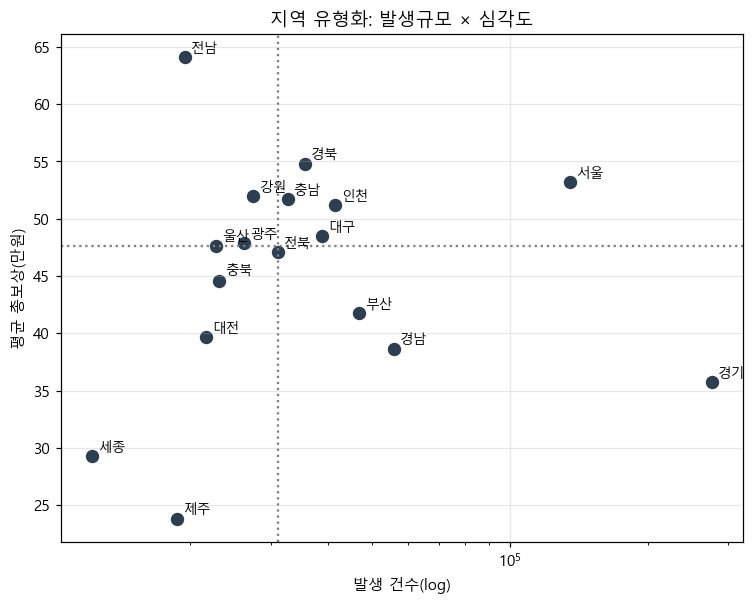

In [12]:
# [그림] 규모(발생) × 심각도(평균보상) 4분면: 지역 유형화
reg_cnt = occ['지역'].value_counts()
avg = comp.groupby('지역')['총보상'].mean()
df = pd.DataFrame({'발생':reg_cnt, '평균보상':avg}).dropna()
mx, my = df['발생'].median(), df['평균보상'].median()
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(df['발생'], df['평균보상']/1e4, s=60, color='#2c3e50')
for n,r in df.iterrows(): ax.annotate(n,(r['발생'],r['평균보상']/1e4),fontsize=9,xytext=(4,3),textcoords='offset points')
ax.axvline(mx,color='gray',ls=':'); ax.axhline(my/1e4,color='gray',ls=':')
ax.set_xscale('log'); ax.set_xlabel('발생 건수(log)'); ax.set_ylabel('평균 총보상(만원)')
ax.set_title('지역 유형화: 발생규모 × 심각도'); ax.grid(alpha=.3)
save('reg_fig5_지역유형화.png'); plt.show()

> - **우상단(많고 심각)**: 서울 — 규모·심각도 모두 상위, 우선관리.
> - **좌상단(적지만 심각)**: 전남·경북·강원 — 접근성·후송 등 *사고 후 관리* 취약 가능성.
> - **우하단(많지만 경미)**: 경기 — 규모는 크나 건당 심각도는 낮음.
> - **좌하단(적고 경미)**: 제주·세종.

In [13]:
# 심화: 실외활동/체육 맥락 비중의 지역차 (심각도 배경 탐색용)
occ['실외運'] = occ['사고장소'].eq('운동장')
occ['체육맥락'] = occ['사고시간'].eq('체육')
comp2 = comp.copy()
prof = pd.DataFrame({
    '운동장사고%': (occ.groupby('지역')['실외運'].mean()*100),
    '체육맥락%':  (occ.groupby('지역')['체육맥락'].mean()*100),
    '평균보상(만)': (comp.groupby('지역')['총보상'].mean()/1e4),
}).round(1).sort_values('평균보상(만)', ascending=False)
print(prof.to_string())

    운동장사고%  체육맥락%  평균보상(만)
지역                        
전남    24.0   31.9     64.1
경북    27.1   32.7     54.8
서울    31.1   39.8     53.2
강원    27.1   33.2     52.0
충남    26.2   32.5     51.7
인천    25.5   35.3     51.2
대구    28.4   37.0     48.5
광주    25.2   36.5     47.9
울산    22.9   33.4     47.7
전북    20.8   28.8     47.1
충북    22.5   33.4     44.6
부산    29.4   33.5     41.8
대전    28.1   39.7     39.7
경남    23.2   34.9     38.6
경기    28.3   38.2     35.7
세종    17.4   32.8     29.2
제주    35.1   36.8     23.8


> 운동장·체육 비중이 특별히 심각도와 단순비례하진 않음 → 지역 심각도차는 활동구성보다 **고액사고(장해·중상) 발생·보상처리 차이**에 더 기인함을 시사(추가 검증 과제).

## 4. 요약 — 지역차, 어디에 있나

| 층위 | 지역차 여부 | 근거 |
|---|---|---|
| 발생 **건수(절대)** | 커 보이나 **학생수 반영** | 경기=제주 15배 → 정규화 필요(KESS) |
| 사고 **유형 구성** | **거의 없음(대동소이)** | Cramér's V 전부 <0.06, 유의하나 효과 미미 |
| **심각도(평균보상)** | **뚜렷함** | 전남 vs 제주 **2.7배** |
| └ 상위1% 제거 후 | **격차↓·선명도↑** | 배수 2.7→1.88, 순위 급변(강원 −54%) |
| └ 가설검정(원본) | 유의하나 **효과 미미** | ANOVA/Welch/KW p≪.001, **η²=0.0002** |
| └ 가설검정(절사) | **유의+효과 뚜렷해짐** | η² 24배↑(0.0048), 유의쌍 26%→74%, g 0.06→0.37 |

**결론**
- "지역별로 사고 *종류*가 다르다"는 근거 약함 → 유형은 전국 공통 패턴.
- "지역별로 사고 *심각도·비용*이 다르다"는 **가설검정으로 확인**(H0 기각). 단 원자료 효과크기는 미미.
- **반전**: 소수 고액사고를 제거하면 효과크기가 커진다 → 지역차의 본질은 *일상 사고비용 수준*의 체계적 차이이며, 고액사고는 지역 무관 랜덤 잡음. **제주·세종·경기(저) vs 광주·전남·울산(고)** 가 통계적으로 지지됨.
- 발생률 지역비교는 **학생수 정규화 데이터 확보가 전제**.

**다음 단계**: ① KESS 학생수 결합 → 1천명당 발생률 지도 ② 지역별 고액사고(장해·중상) *비율* 심층 — 왜 강원·전남에 중증사고가 몰리나(후송거리·시설·종목) ③ 도농/기후 변수 결합(운동장 사고 지역차 설명).

> 그림: `Docs/figures/reg_fig1~5.png`